# Paper figures — interactive tuning

Every plot has its own cell with knobs at the top. Edit a knob, rerun the cell, the figure refreshes inline. Pass `output_dir=OUTPUT_DIR` to also write the PNG (filename matches `plot_results.py`).

Coverage matches `plot_results.py`:
- **RQ1 (drift)** — sliding-window precision/recall/F1 boxplot per drift scenario
- **RQ2 (adaptation)** — RE/abs-err box + success-rate bars per drift scenario
- **RQ3 (cost)** — mixed-cost boxplot, per-method heatmap, online per-drift, online combined

In [64]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import helpers

LOG_DIR = 'logs'
OUTPUT_DIR = 'plots'   # set to None to skip saving while iterating
DPI = 150

# Shared style — used as defaults; override per cell as needed.
COLORS = {
    'Stacking-Online': '#E24A33',
    'BMA':             '#988ED5',
    'Best-Logit':      '#8EBA42',
    'Stacking':        '#DD8452',
    'MCMC':            '#4C72B0',
    'BAS':             '#55A868',
}
METHODS = ['Stacking-Online', 'BMA', 'Best-Logit']

plt.rcParams.update({
    'font.size':       14,
    'axes.labelsize':  18,
    'axes.titlesize':  16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.dpi':      DPI,
    'legend.fontsize': 12,
})

print('RQ1 runs:', helpers.discover_rq1_runs(LOG_DIR))
print('RQ2 runs:', helpers.discover_rq2_runs(LOG_DIR))
print('RQ3 online runs:', helpers.discover_rq3_online(LOG_DIR))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
RQ1 runs: [(0.035, '1x', 'rq4_A_th0.035_drift1x.json'), (0.035, '3x', 'rq4_A_th0.035_drift3x.json'), (0.035, '6x', 'rq4_A_th0.035_drift6x.json'), (0.035, 'perm_late', 'rq4_A_th0.035_driftperm_late.json'), (0.035, 'perm_mid', 'rq4_A_th0.035_driftperm_mid.json'), (0.035, 'recurring', 'rq4_A_th0.035_driftrecurring.json')]
RQ2 runs: [(0.035, '1x', 'logit', 'match-drift', 'rq2_A_drift1x_th0.035_oraclelogit_oraclelabelsmatch-drift.json'), (0.035, '3x', 'logit', 'match-drift', 'rq2_A_drift3x_th0.035_oraclelogit_oraclelabelsmatch-drift.json'), (0.035, '6x', 'logit', 'match-drift', 'rq2_A_drift6x_th0.035_oraclelogit_oraclelabelsmatch-drift.json')]
RQ3 online runs: [('1x', 'rq3_online_grid_drift1x_re100.tsv', 'grid'), ('1x', 'rq3_online_grid_drift1x_re77.tsv', 'grid'), ('3x', 'rq3_online_grid_drift3x_re100.tsv', 'grid'), ('6x', 'rq3_online_grid_drift6x_re100.tsv', 'grid')]


---
## RQ1 — sliding-window metric boxplot

One panel per (drift scenario × metric). Tune box style / window / fliers.

In [65]:
RQ1_THRESHOLD = 0.035
RQ1_SCENARIO  = '6x'           # one of '1x', '3x', '6x'
RQ1_METRIC    = 'f1'           # 'precision' | 'recall' | 'f1'
RQ1_WINDOW    = 50
RQ1_FIGSIZE   = (7, 5)
RQ1_SHOWFLIERS = True
RQ1_BOX_ALPHA  = 0.7
RQ1_YLIM       = (0.0, 1.05)
RQ1_GRID_ALPHA = 0.3

fig = helpers.plot_rq1_metric_box(
    LOG_DIR, RQ1_THRESHOLD, RQ1_SCENARIO, RQ1_METRIC,
    methods=METHODS, colors=COLORS,
    window=RQ1_WINDOW, figsize=RQ1_FIGSIZE,
    showfliers=RQ1_SHOWFLIERS, box_alpha=RQ1_BOX_ALPHA,
    ylim=RQ1_YLIM, grid_alpha=RQ1_GRID_ALPHA,
    output_dir=OUTPUT_DIR, dpi=DPI,
)

  saved: plots/rq1_A_th0.035_drift6x_f1_box.png


  saved: plots/rq1_A_th0.035_drift1x_precision_box.png


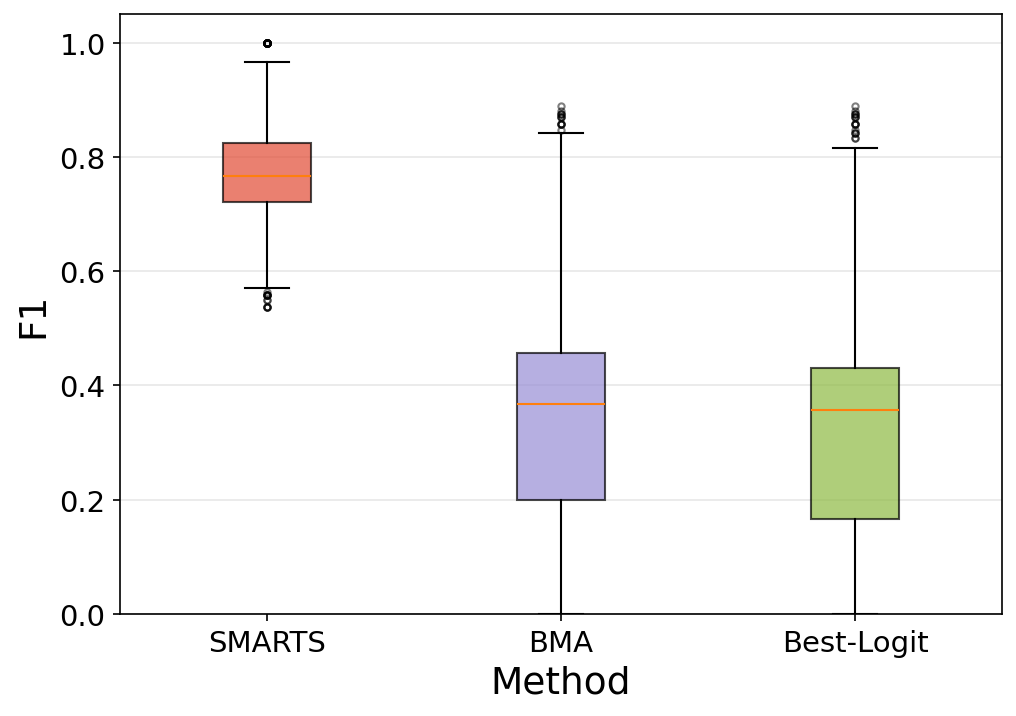

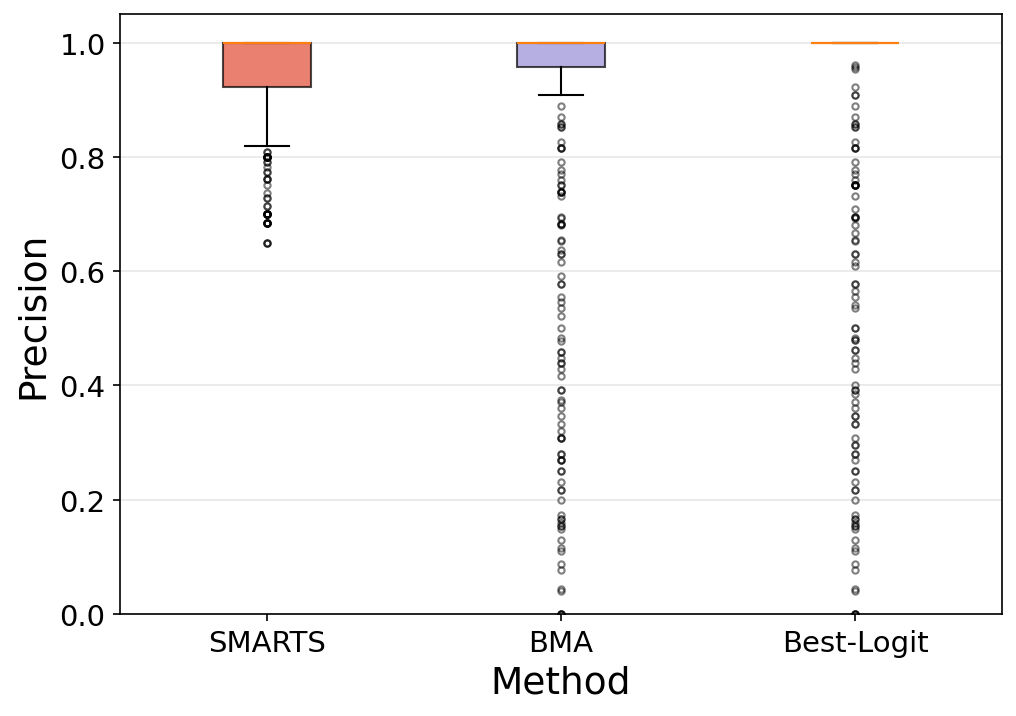

  saved: plots/rq1_A_th0.035_drift1x_recall_box.png


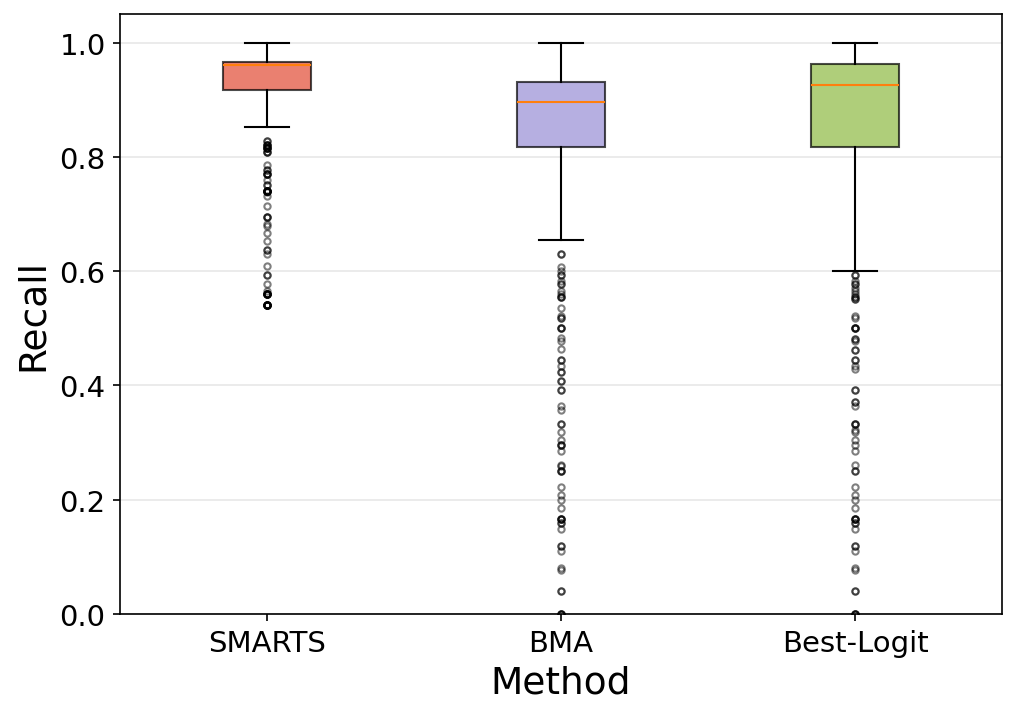

  saved: plots/rq1_A_th0.035_drift1x_f1_box.png


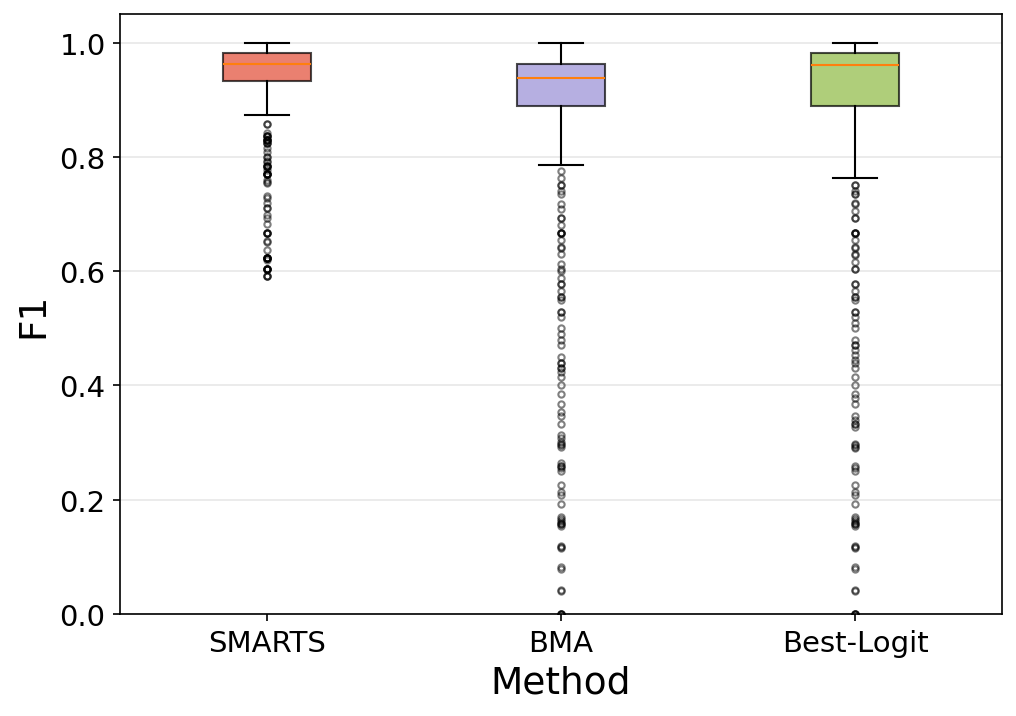

  saved: plots/rq1_A_th0.035_drift3x_precision_box.png


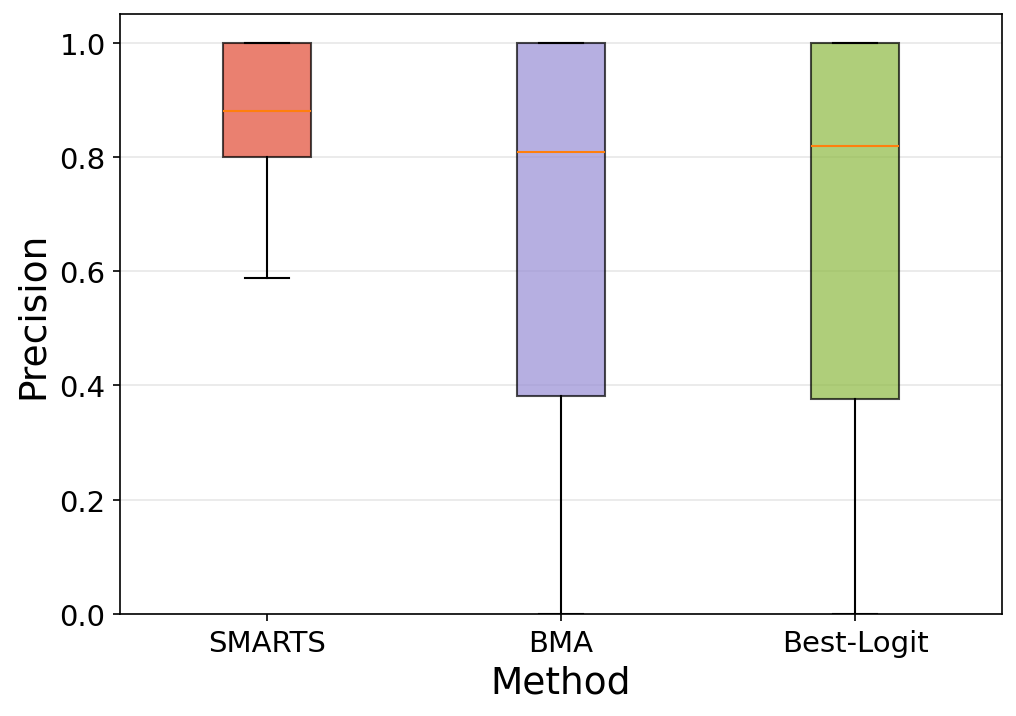

  saved: plots/rq1_A_th0.035_drift3x_recall_box.png


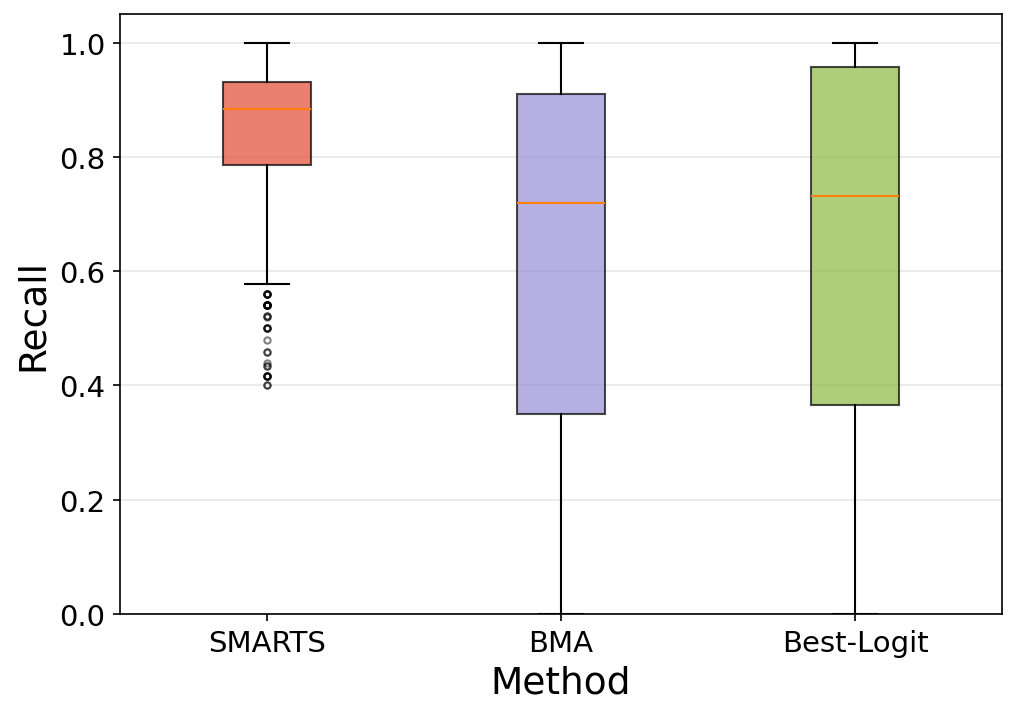

  saved: plots/rq1_A_th0.035_drift3x_f1_box.png


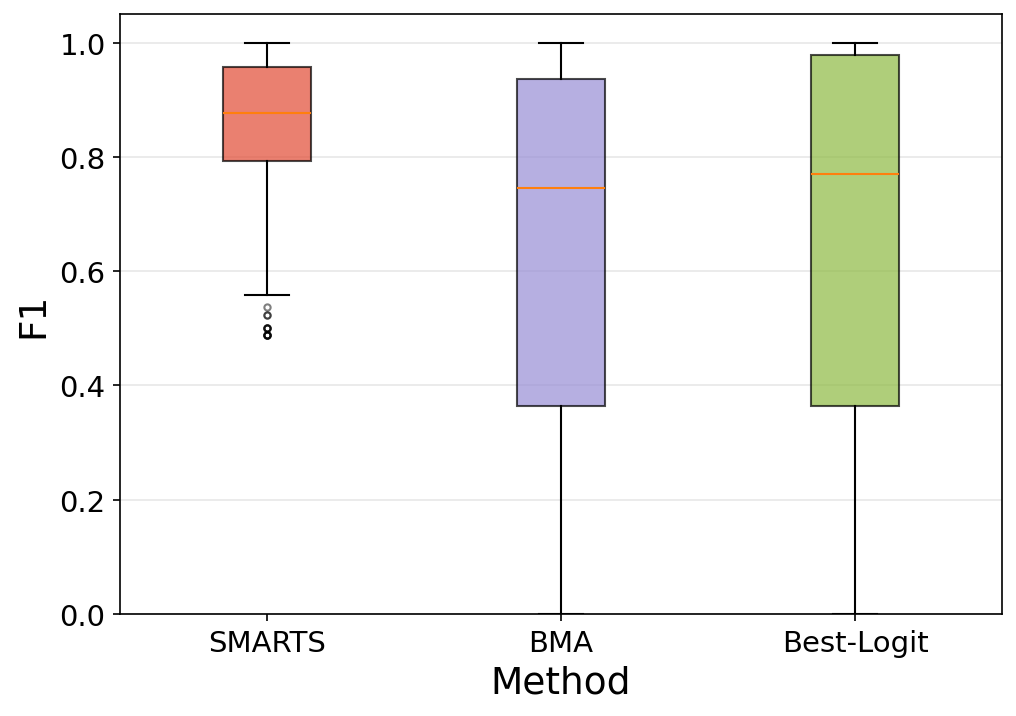

  saved: plots/rq1_A_th0.035_drift6x_precision_box.png


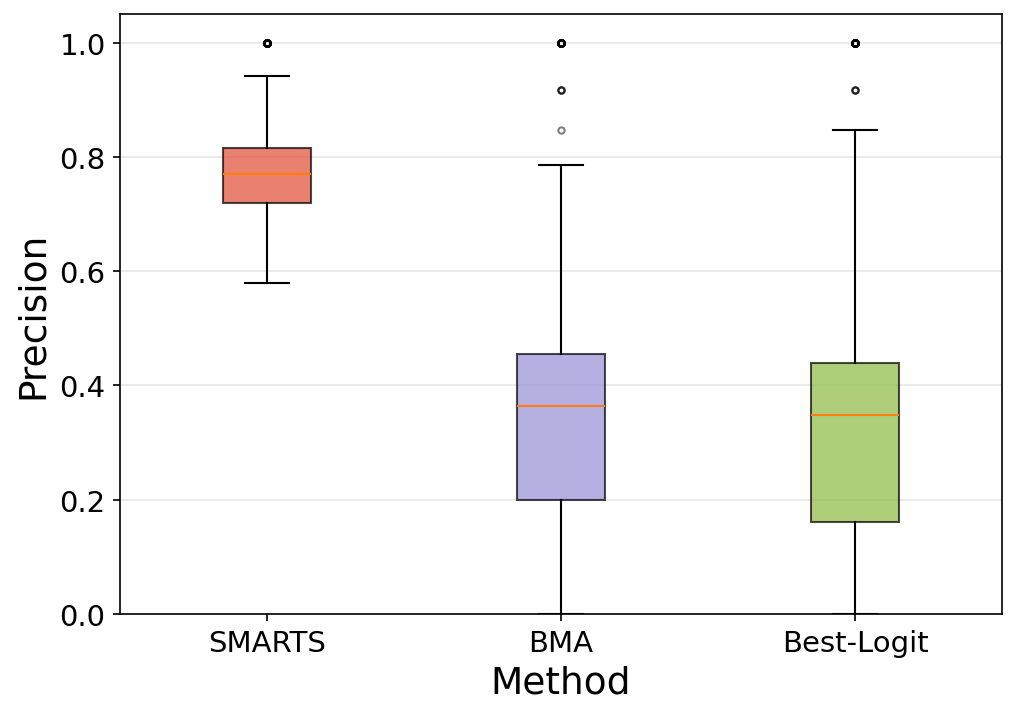

  saved: plots/rq1_A_th0.035_drift6x_recall_box.png


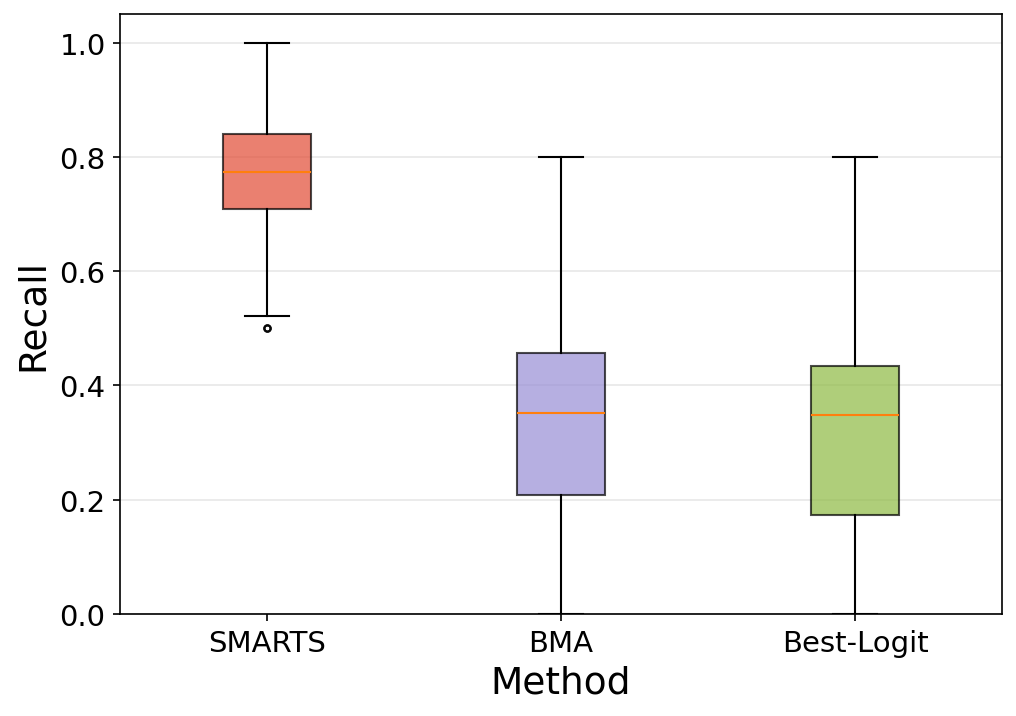

  saved: plots/rq1_A_th0.035_drift6x_f1_box.png


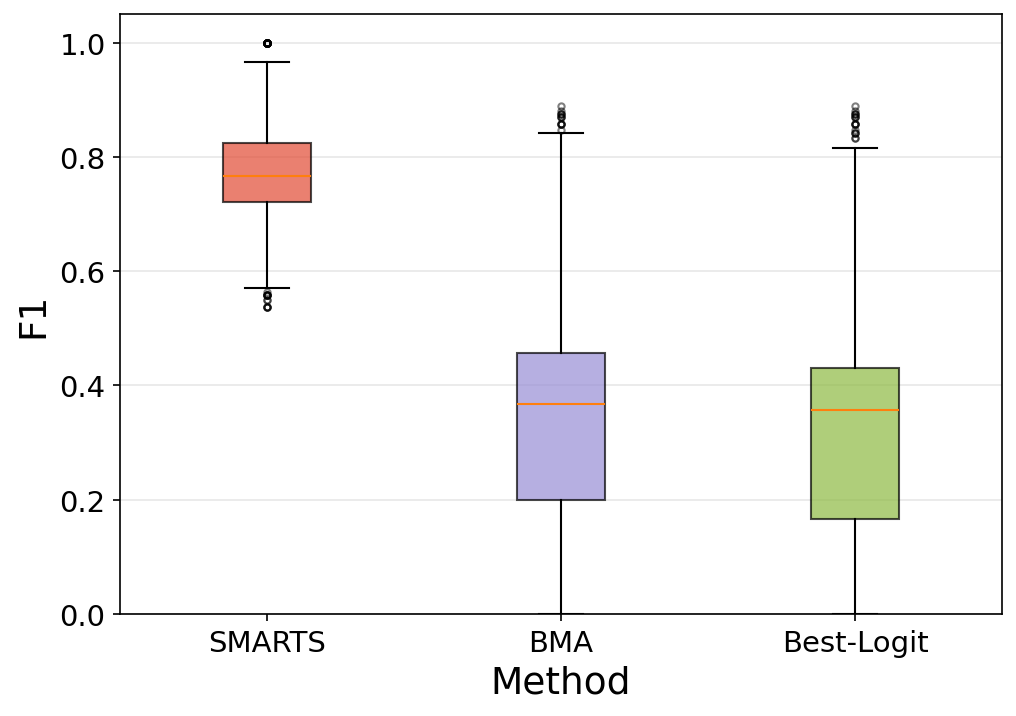

In [66]:
# Generate every RQ1 panel (3 scenarios × 3 metrics) with shared knobs.
for sc in ['1x', '3x', '6x']:
    for metric in ['precision', 'recall', 'f1']:
        fig = helpers.plot_rq1_metric_box(
            LOG_DIR, RQ1_THRESHOLD, sc, metric,
            methods=METHODS, colors=COLORS,
            window=RQ1_WINDOW, figsize=RQ1_FIGSIZE,
            showfliers=RQ1_SHOWFLIERS, box_alpha=RQ1_BOX_ALPHA,
            ylim=RQ1_YLIM, grid_alpha=RQ1_GRID_ALPHA,
            output_dir=OUTPUT_DIR, dpi=DPI,
        )
        plt.show()

---
## RQ2 — RE / abs_err box + success-rate bars

  saved: plots/rq2_A_drift6x_th0.035_oraclelogit_oraclelabelsmatch-drift_metric_box.png
  saved: plots/rq2_A_drift6x_th0.035_oraclelogit_oraclelabelsmatch-drift_success_bars.png


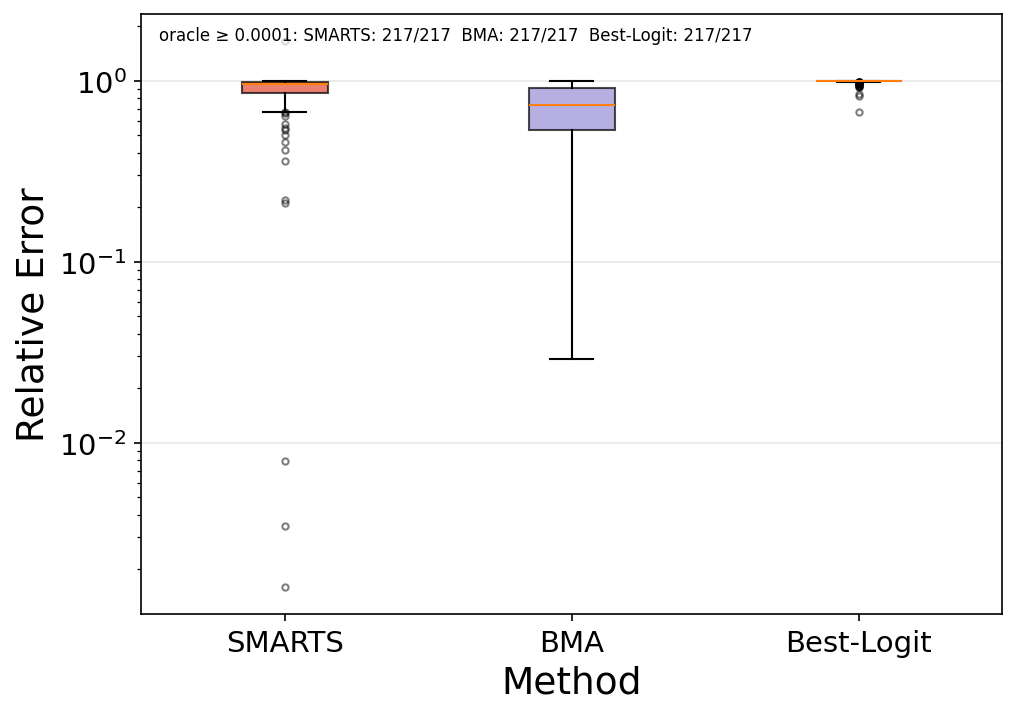

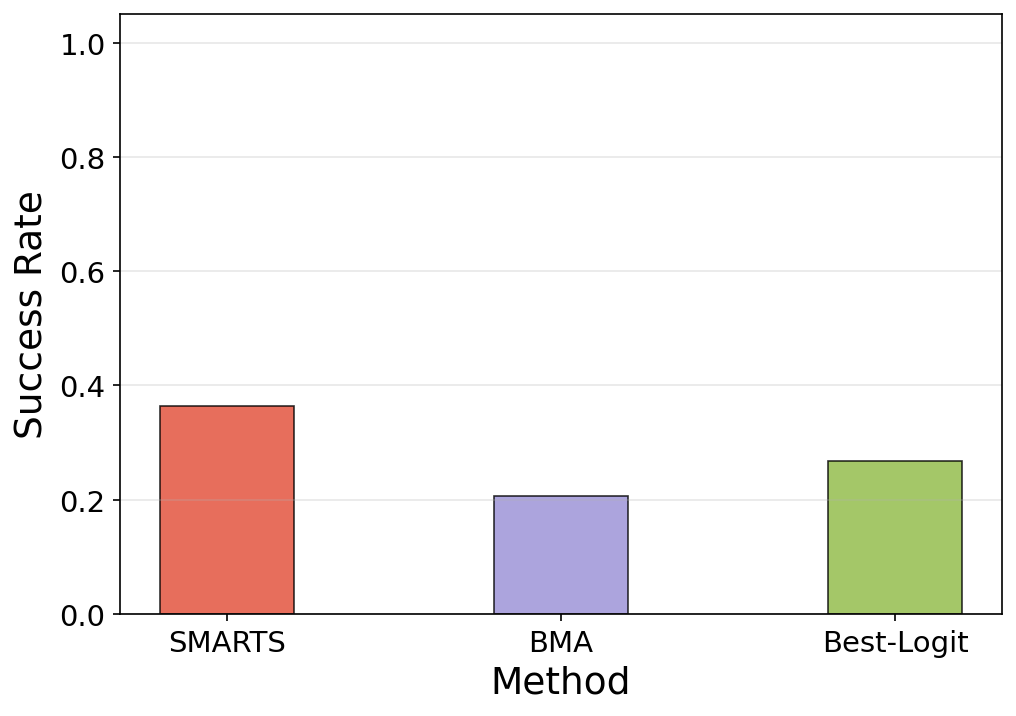

In [67]:
RQ2_THRESHOLD          = 0.035
RQ2_DRIFT              = '6x'
RQ2_ORACLE             = 'logit'
RQ2_ORACLE_LABEL_SRC   = 'match-drift'
RQ2_RE_ORACLE_EPS      = 1e-4
RQ2_FIGSIZE            = (7, 5)
RQ2_SHOWFLIERS         = True
RQ2_BOX_ALPHA          = 0.7
RQ2_GRID_ALPHA         = 0.3
RQ2_ANNOTATE_KEPT      = True
RQ2_BAR_ALPHA          = 0.8
RQ2_BAR_EDGE           = 'black'
RQ2_BAR_WIDTH          = 0.4           # 1.0 = bars touch; 0.5 = half-width; ≈0.6 looks balanced
RQ2_BAR_EDGE_WIDTH     = 0.8
RQ2_BAR_YLIM           = (0.0, 1.05)

fig_box = helpers.plot_rq2_metric_box(
    LOG_DIR, RQ2_THRESHOLD,
    drift=RQ2_DRIFT, oracle=RQ2_ORACLE, oracle_label_source=RQ2_ORACLE_LABEL_SRC,
    methods=METHODS, colors=COLORS,
    re_oracle_eps=RQ2_RE_ORACLE_EPS,
    figsize=RQ2_FIGSIZE, showfliers=RQ2_SHOWFLIERS,
    box_alpha=RQ2_BOX_ALPHA, grid_alpha=RQ2_GRID_ALPHA,
    annotate_kept=RQ2_ANNOTATE_KEPT,
    output_dir=OUTPUT_DIR, dpi=DPI,
)
# plt.show()

fig_bar = helpers.plot_rq2_success_bars(
    LOG_DIR, RQ2_THRESHOLD,
    drift=RQ2_DRIFT, oracle=RQ2_ORACLE, oracle_label_source=RQ2_ORACLE_LABEL_SRC,
    methods=METHODS, colors=COLORS,
    figsize=RQ2_FIGSIZE, bar_alpha=RQ2_BAR_ALPHA, bar_width=RQ2_BAR_WIDTH,
    edge_color=RQ2_BAR_EDGE, edge_width=RQ2_BAR_EDGE_WIDTH,
    ylim=RQ2_BAR_YLIM, grid_alpha=RQ2_GRID_ALPHA,
    output_dir=OUTPUT_DIR, dpi=DPI,
)
plt.show()

  saved: plots/rq2_A_drift1x_th0.035_oraclelogit_oraclelabelsmatch-drift_metric_box.png


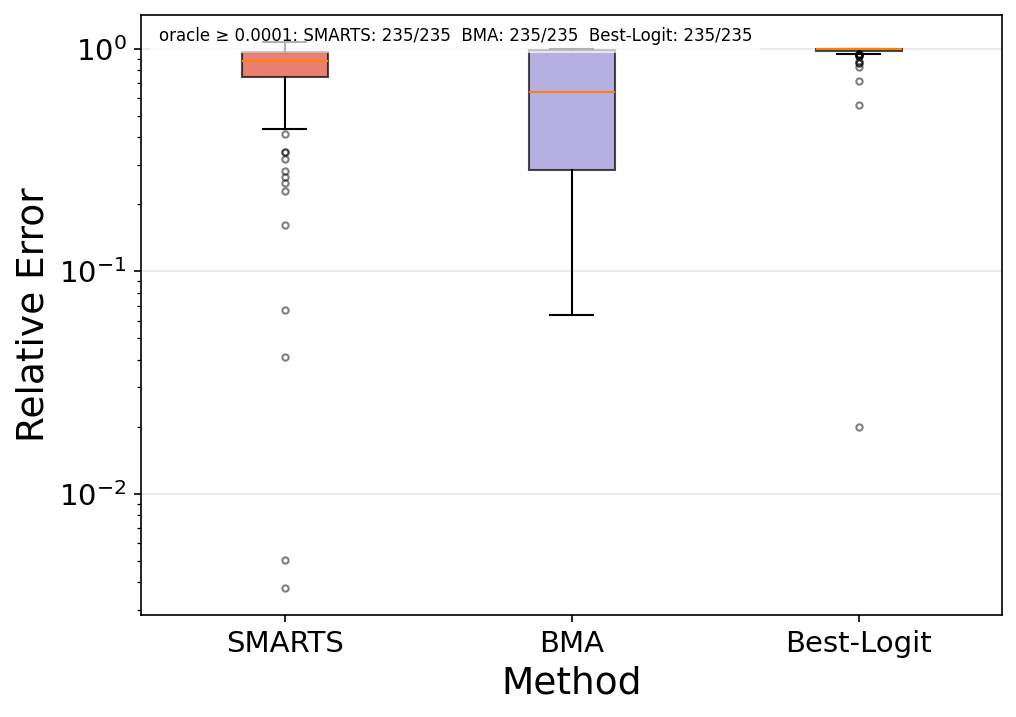

  saved: plots/rq2_A_drift1x_th0.035_oraclelogit_oraclelabelsmatch-drift_success_bars.png


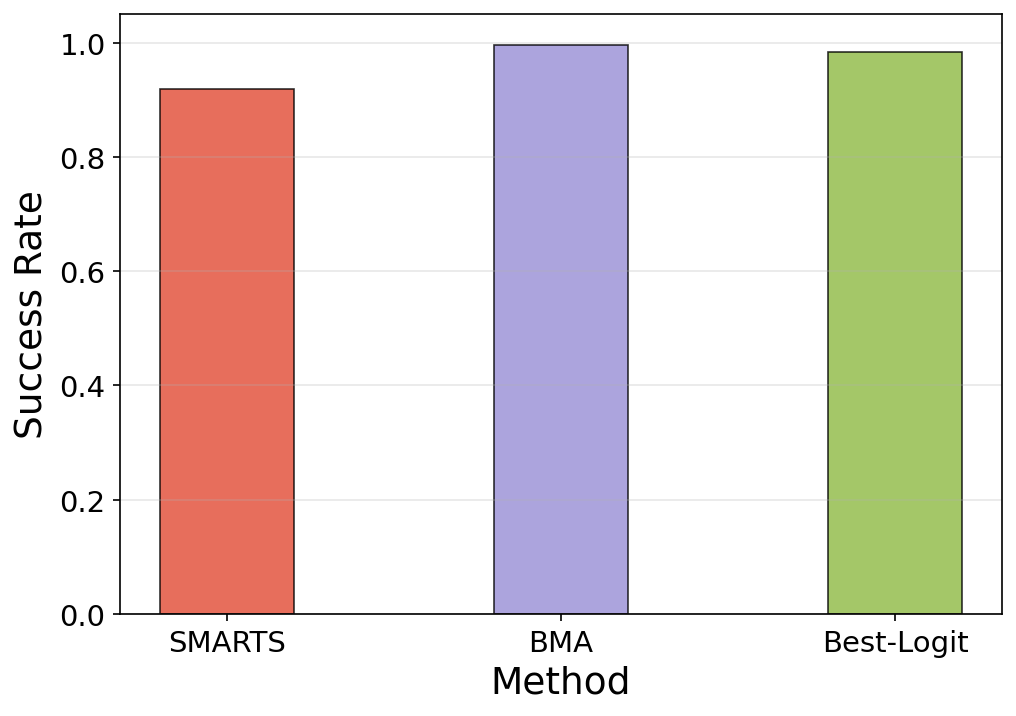

  saved: plots/rq2_A_drift3x_th0.035_oraclelogit_oraclelabelsmatch-drift_metric_box.png


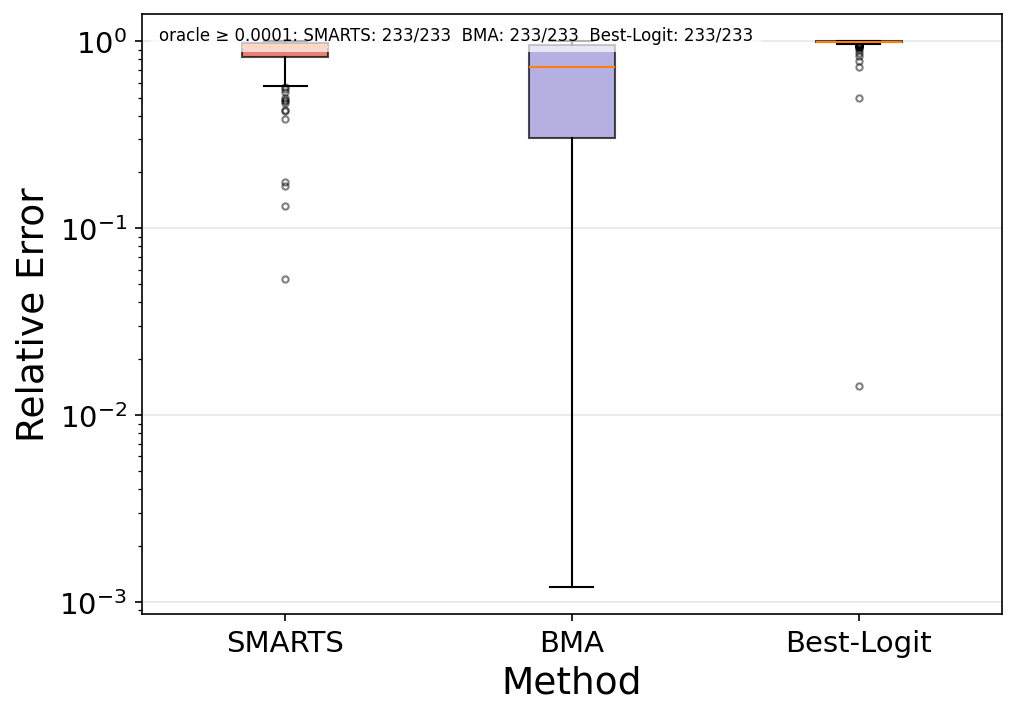

  saved: plots/rq2_A_drift3x_th0.035_oraclelogit_oraclelabelsmatch-drift_success_bars.png


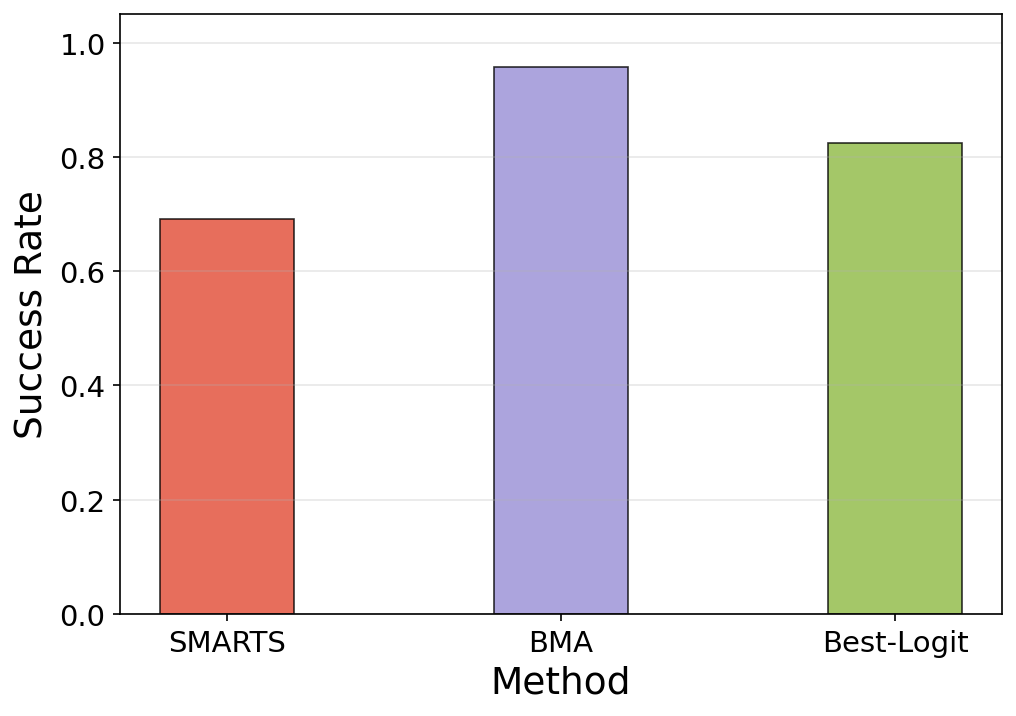

  saved: plots/rq2_A_drift6x_th0.035_oraclelogit_oraclelabelsmatch-drift_metric_box.png


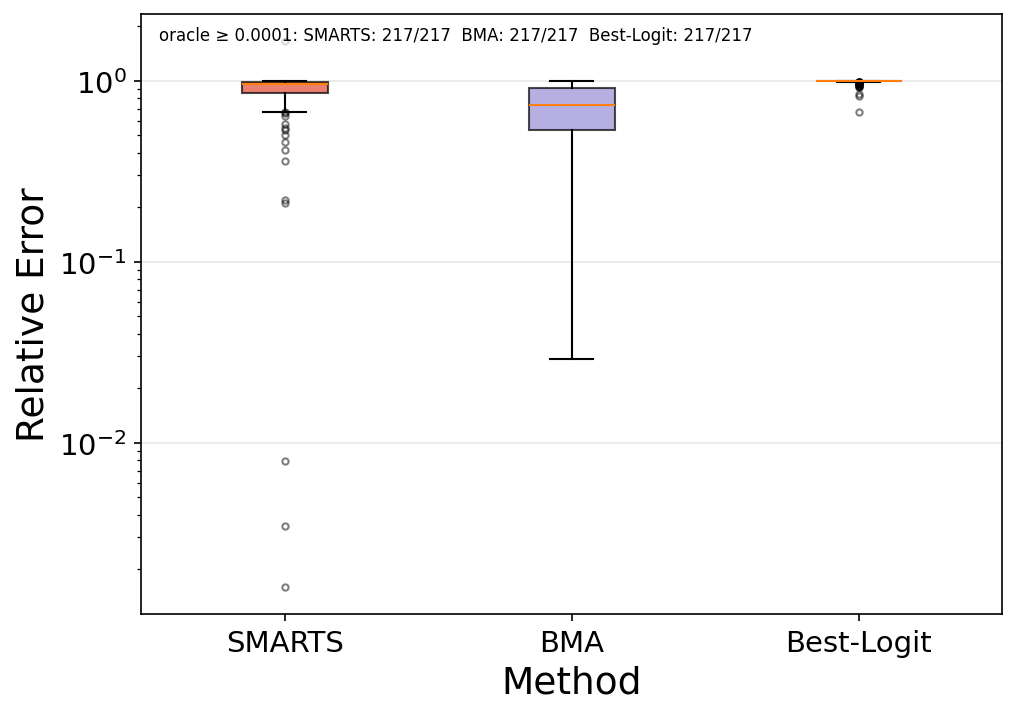

  saved: plots/rq2_A_drift6x_th0.035_oraclelogit_oraclelabelsmatch-drift_success_bars.png


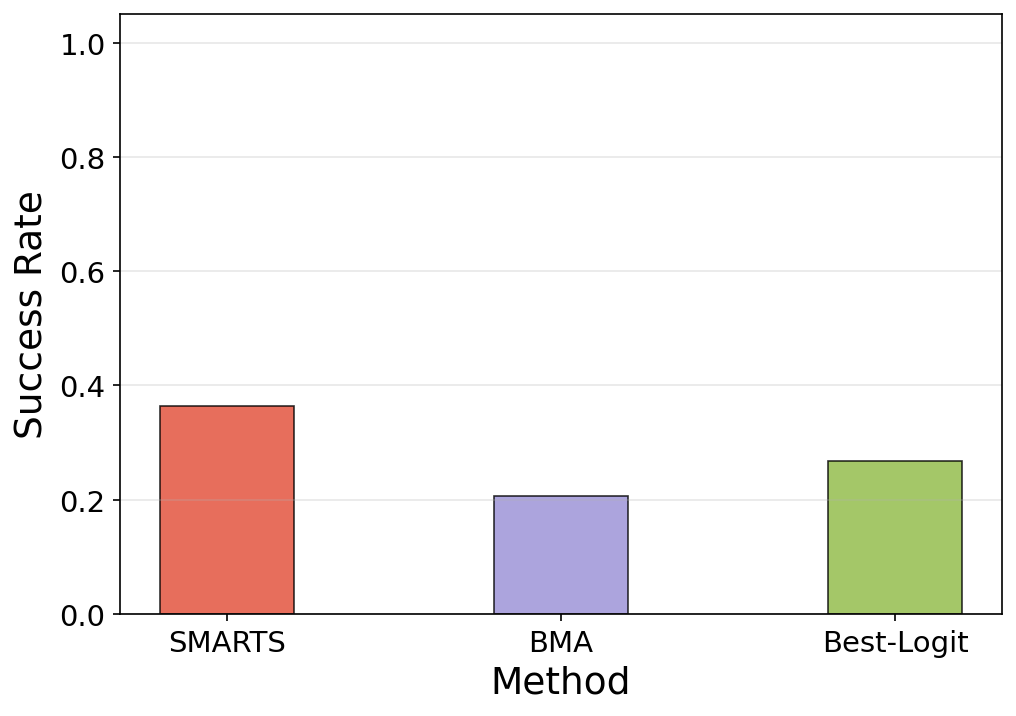

In [68]:
# Generate RQ2 figures for every drift scenario at once.
for drift in ['1x', '3x', '6x']:
    fb = helpers.plot_rq2_metric_box(
        LOG_DIR, RQ2_THRESHOLD,
        drift=drift, oracle=RQ2_ORACLE, oracle_label_source=RQ2_ORACLE_LABEL_SRC,
        methods=METHODS, colors=COLORS,
        re_oracle_eps=RQ2_RE_ORACLE_EPS, figsize=RQ2_FIGSIZE,
        showfliers=RQ2_SHOWFLIERS, box_alpha=RQ2_BOX_ALPHA,
        grid_alpha=RQ2_GRID_ALPHA, annotate_kept=RQ2_ANNOTATE_KEPT,
        output_dir=OUTPUT_DIR, dpi=DPI,
    )
    plt.show()
    fr = helpers.plot_rq2_success_bars(
        LOG_DIR, RQ2_THRESHOLD,
        drift=drift, oracle=RQ2_ORACLE, oracle_label_source=RQ2_ORACLE_LABEL_SRC,
        methods=METHODS, colors=COLORS,
        figsize=RQ2_FIGSIZE, bar_alpha=RQ2_BAR_ALPHA, bar_width=RQ2_BAR_WIDTH,
        edge_color=RQ2_BAR_EDGE, edge_width=RQ2_BAR_EDGE_WIDTH,
        ylim=RQ2_BAR_YLIM, grid_alpha=RQ2_GRID_ALPHA,
        output_dir=OUTPUT_DIR, dpi=DPI,
    )
    plt.show()

---
## RQ3 — mixed-cost boxplot

Best-Logit fit time + SMARTS/BMA online_update latency under one drift scenario.

In [69]:
RQ3_DRIFT          = '6x'
RQ3_RETRAIN_EVERY  = 100
RQ3_TIMEOUT_S      = 200
RQ3_FIGSIZE        = (7, 5)
RQ3_BOX_WIDTHS     = 0.35
RQ3_BOX_ALPHA      = 0.7
RQ3_SHOWFLIERS     = True
RQ3_GRID_ALPHA     = 0.3

fig = helpers.plot_rq3_boxplot_single(
    LOG_DIR,
    drift_scenario=RQ3_DRIFT, retrain_every=RQ3_RETRAIN_EVERY,
    colors=COLORS, timeout_s=RQ3_TIMEOUT_S,
    figsize=RQ3_FIGSIZE, box_widths=RQ3_BOX_WIDTHS,
    box_alpha=RQ3_BOX_ALPHA, showfliers=RQ3_SHOWFLIERS,
    grid_alpha=RQ3_GRID_ALPHA,
    output_dir=OUTPUT_DIR, dpi=DPI,
)
# plt.show()

  saved: plots/rq3_boxplot.png


## RQ3 — heatmap (sample × vars × time)

Builds one heatmap per method available in `logs/rq3_*.tsv` (or the baseline TSV).

  saved: plots/rq3_heatmap_Best-Logit.png
method = Best-Logit


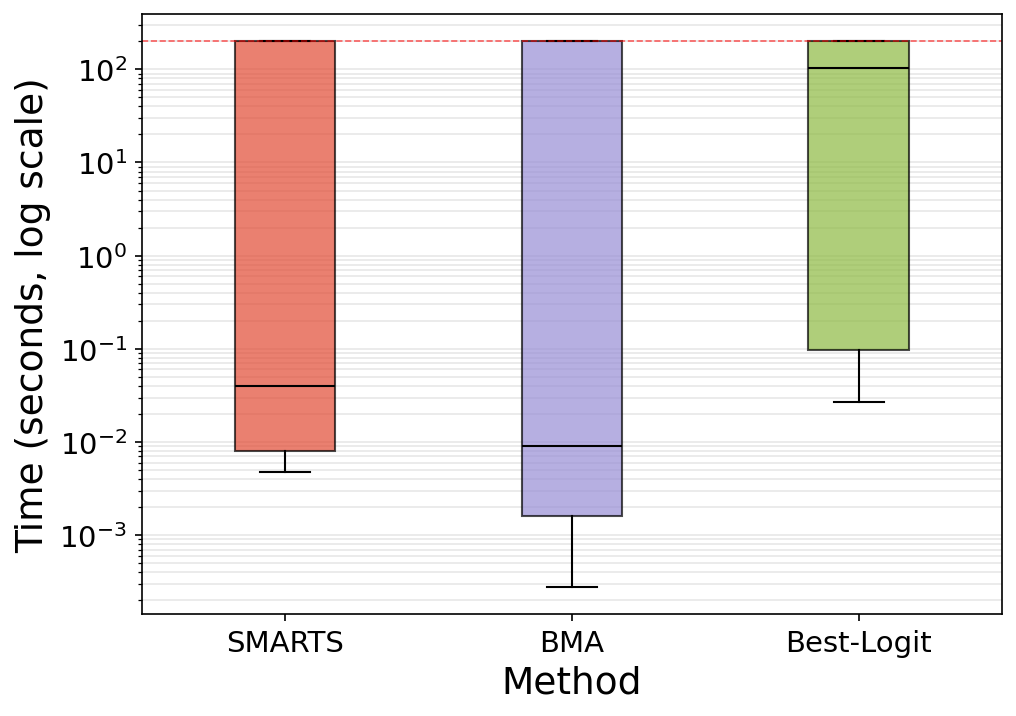

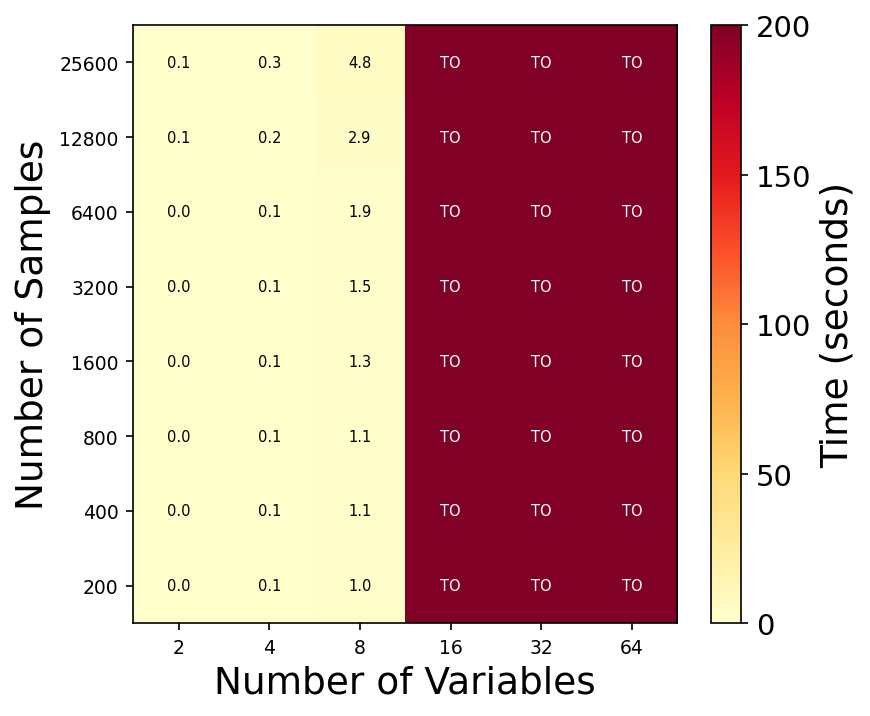

In [70]:
RQ3_HEATMAP_CMAP        = 'YlOrRd'
RQ3_HEATMAP_FIGSIZE     = (6, 5)
RQ3_HEATMAP_FONTSIZE    = 7
RQ3_HEATMAP_METHOD      = None       # None = all methods, or a single name

figs = helpers.plot_rq3_heatmap(
    LOG_DIR, method=RQ3_HEATMAP_METHOD,
    timeout_s=RQ3_TIMEOUT_S, cmap=RQ3_HEATMAP_CMAP,
    figsize=RQ3_HEATMAP_FIGSIZE, annot_fontsize=RQ3_HEATMAP_FONTSIZE,
    output_dir=OUTPUT_DIR, dpi=DPI,
)
for m, fig in figs.items():
    print(f'method = {m}')
    plt.show()

## RQ3 — online heatmap (sample × vars × cost)

Heatmap built from RQ3-B online grid data. Produces 
`rq3_heatmap_Stacking.png` and `rq3_heatmap_BMA.png` (matches the canonical 
filenames in /plots/). `value_col` chooses the cost statistic shown:
- `total` (default): full stream processing time
- `time`: per-sample latency
- `median` / `p95`: per-sample latency stats

  saved: plots/rq3_heatmap_Stacking.png
  saved: plots/rq3_heatmap_BMA.png
label = Stacking


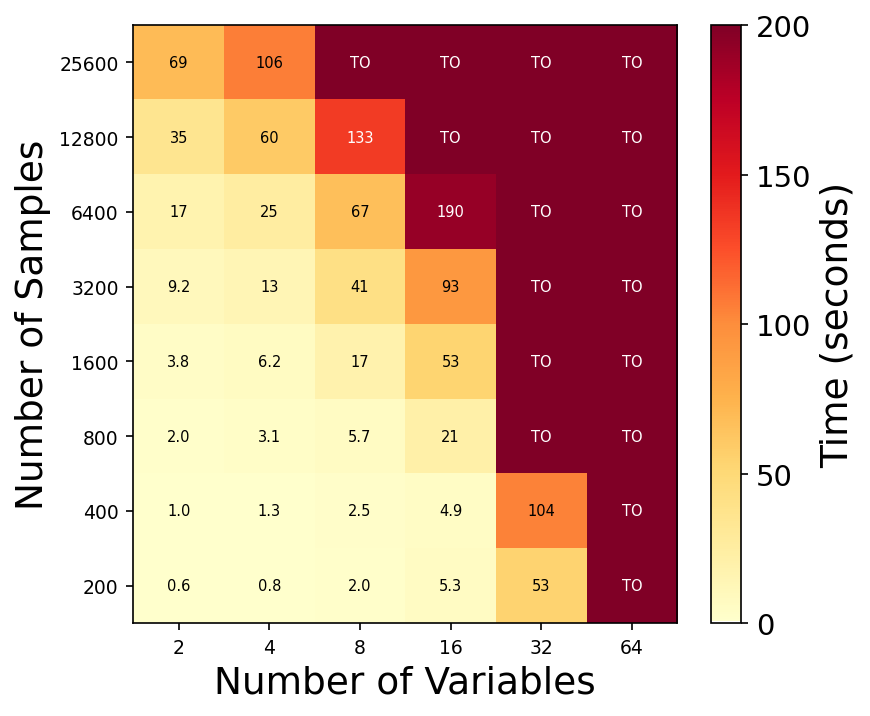

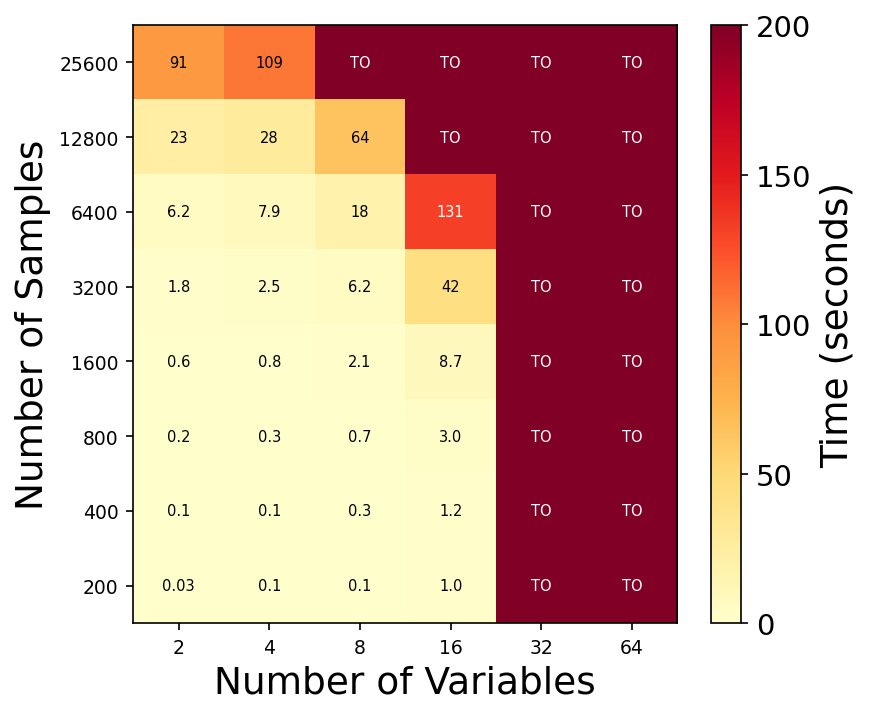

label = BMA


In [71]:
RQ3_ONLINE_HEATMAP_DRIFT      = "6x"
RQ3_ONLINE_HEATMAP_VALUE_COL  = "total"     # "total" | "time" | "median" | "p95"
RQ3_ONLINE_HEATMAP_CMAP       = "YlOrRd"
RQ3_ONLINE_HEATMAP_FIGSIZE    = (6, 5)
RQ3_ONLINE_HEATMAP_FONTSIZE   = 7

figs = helpers.plot_rq3_online_heatmap(
    LOG_DIR,
    scenario=RQ3_ONLINE_HEATMAP_DRIFT,
    retrain_every=RQ3_RETRAIN_EVERY,
    value_col=RQ3_ONLINE_HEATMAP_VALUE_COL,
    timeout_s=RQ3_TIMEOUT_S,
    cmap=RQ3_ONLINE_HEATMAP_CMAP,
    figsize=RQ3_ONLINE_HEATMAP_FIGSIZE,
    annot_fontsize=RQ3_ONLINE_HEATMAP_FONTSIZE,
    output_dir=OUTPUT_DIR, dpi=DPI,
)
for label, fig in figs.items():
    print(f"label = {label}")
    plt.show()


In [72]:
helpers.run_all(log_dir=LOG_DIR, output_dir=OUTPUT_DIR,
                retrain_every=RQ3_RETRAIN_EVERY, threshold=0.035)

RQ1: drift
  saved: plots/rq1_A_th0.035_drift1x_precision_box.png
  saved: plots/rq1_A_th0.035_drift1x_recall_box.png
  saved: plots/rq1_A_th0.035_drift1x_f1_box.png
  saved: plots/rq1_A_th0.035_drift3x_precision_box.png
  saved: plots/rq1_A_th0.035_drift3x_recall_box.png
  saved: plots/rq1_A_th0.035_drift3x_f1_box.png
  saved: plots/rq1_A_th0.035_drift6x_precision_box.png
  saved: plots/rq1_A_th0.035_drift6x_recall_box.png
  saved: plots/rq1_A_th0.035_drift6x_f1_box.png
RQ2: adaptation decisions
  saved: plots/rq2_A_drift1x_th0.035_oraclelogit_oraclelabelsmatch-drift_metric_box.png
  saved: plots/rq2_A_drift1x_th0.035_oraclelogit_oraclelabelsmatch-drift_success_bars.png
  saved: plots/rq2_A_drift3x_th0.035_oraclelogit_oraclelabelsmatch-drift_metric_box.png
  saved: plots/rq2_A_drift3x_th0.035_oraclelogit_oraclelabelsmatch-drift_success_bars.png
  saved: plots/rq2_A_drift6x_th0.035_oraclelogit_oraclelabelsmatch-drift_metric_box.png
  saved: plots/rq2_A_drift6x_th0.035_oraclelogit_oracl